ωg = 5.60e+14 rad/s
ωe = 5.08e+14 rad/s
Ground state minimum:
R = 1.2740913637879294 Å
Energy = 1.3285502358200704e-07 eV

Excited state minimum:
R = 1.54918306102034 Å
Energy = 8.600008747584335 eV
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


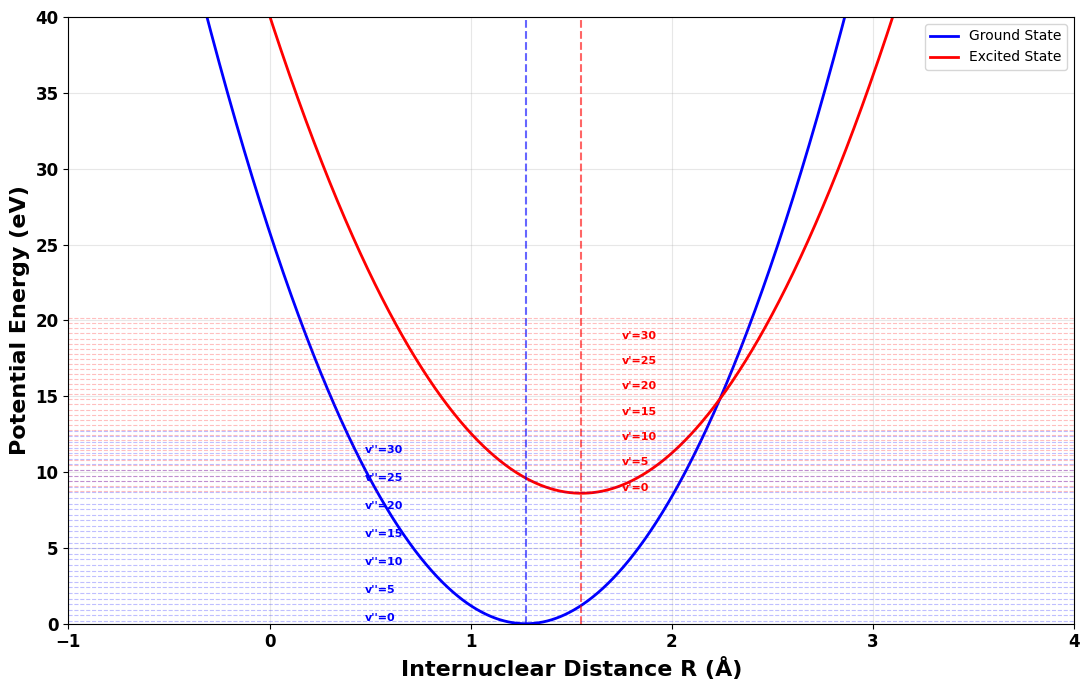

In [ ]:
#HCL (K, dyne/cm)
import numpy as np
import matplotlib.pyplot as plt


class FranckCondonCalculator:
   """
   Franck-Condon diagram for diatomic molecules
   with dynamic plotting and 35 vibrational levels
   """

   def __init__(self, molecule_data):
       self.Re_g = molecule_data['Re_g']
       self.Re_e = molecule_data['Re_e']
       self.k_g = molecule_data['k_g']
       self.k_e = molecule_data['k_e']
       self.mu = molecule_data['mu']
       self.E_e = molecule_data['E_e']

       self._calculate_frequencies()

   def _calculate_frequencies(self):
      # Convert dyne/cm → N/m
       self.k_g_SI = self.k_g * 1e-3
       self.k_e_SI = self.k_e * 1e-3

       # Angular frequencies
       self.omega_g = np.sqrt(self.k_g_SI / self.mu)
       self.omega_e = np.sqrt(self.k_e_SI / self.mu)

       print(f"ωg = {self.omega_g:.2e} rad/s")
       print(f"ωe = {self.omega_e:.2e} rad/s")

   def _compute_vibrational_levels(self):
       max_v = 35

       hbar = 1.054571817e-34
       eV_to_J = 1.602176634e-19

       E_vib_g = [(v + 0.5) * hbar * self.omega_g / eV_to_J for v in range(max_v)]
       E_vib_e = [(v + 0.5) * hbar * self.omega_e / eV_to_J + self.E_e for v in range(max_v)]

       return E_vib_g, E_vib_e, max_v

   def plot_potential_curves_and_levels(self):
       # 🔥 Smart R range (centered around both wells)
       R_min = -1.0
       R_max = 4.0
       R = np.linspace(R_min, R_max, 3000)

       # Potential curves
       self.k_g_plot = self.k_g/16021.76634
       self.k_e_plot = self.k_e/16021.76634

       V_g = 0.5 * self.k_g_plot * (R - self.Re_g) ** 2
       V_e = self.E_e + 0.5 * self.k_e_plot * (R - self.Re_e) ** 2
       # Ground state minimum (from plotted data)
       min_g_index = np.argmin(V_g)
       print("Ground state minimum:")
       print("R =", R[min_g_index], "Å")
       print("Energy =", V_g[min_g_index], "eV")

       # Excited state minimum
       min_e_index = np.argmin(V_e)
       print("\nExcited state minimum:")
       print("R =", R[min_e_index], "Å")
       print("Energy =", V_e[min_e_index], "eV")
       # Vibrational levels
       E_vib_g, E_vib_e, max_v = self._compute_vibrational_levels()

       plt.figure(figsize=(11, 7))

       # 🔵 Ground, 🔴 Excited
       plt.plot(R, V_g, color='blue', linewidth=2, label='Ground State')
       plt.plot(R, V_e, color='red', linewidth=2, label='Excited State')

       # Equilibrium positions
       plt.axvline(self.Re_g, color='blue', linestyle='--', alpha=0.6)
       plt.axvline(self.Re_e, color='red', linestyle='--', alpha=0.6)

       # Vibrational levels (clean + readable)
       for v in range(max_v):
           plt.axhline(E_vib_g[v], color='blue', linestyle='--', alpha=0.25, linewidth=0.8)
           plt.axhline(E_vib_e[v], color='red', linestyle='--', alpha=0.25, linewidth=0.8)

           # Label every 5th level
           if v % 5 == 0:
               plt.text(self.Re_g - 0.8, E_vib_g[v], f"v''={v}", fontsize=8, weight='bold', color='blue')
               plt.text(self.Re_e + 0.2, E_vib_e[v], f"v'={v}", fontsize=8, weight='bold', color='red')


       plt.ylim(0,40)
       plt.xlim(-1.0, 4.0)
       # Labels and styling
       plt.xlabel('Internuclear Distance R (Å)', fontsize=16, weight='bold')
       plt.ylabel('Potential Energy (eV)', fontsize=16, weight='bold')
       plt.xticks(fontsize=12, weight='bold')  # Increase font size for x axis tick marks
       plt.yticks(fontsize=12, weight='bold')  # Increase font size for y axis tick marks
       plt.legend( fontsize=12)  # Add legend for clarity
       from google.colab import drive
       drive.mount('/content/drive')
       plt.savefig('/content/drive/My Drive/Harmonic/Figure 1.jpg', dpi=300)
       plt.grid(alpha=0.3)
       plt.legend()
       plt.tight_layout()
       plt.savefig("HCl_dynamic.png", dpi=300)
       plt.show()


def main():
   hcl_data = {
       'Re_g': 1.274,
       'Re_e': 1.55,
       'k_g': 5.1e5,
       'k_e': 4.2e5,
       'mu': 1.626e-27,
       'E_e': 8.6
   }

   print("=" * 40)

   fc_calc = FranckCondonCalculator(hcl_data)
   fc_calc.plot_potential_curves_and_levels()


if __name__ == "__main__":
   main()


ωg = 5.63e+14 rad/s
ωe = 5.08e+14 rad/s
Ground state minimum:
R = 1.2740913637879294 Å
Energy = 1.34392202091413e-07 eV

Excited state minimum:
R = 1.54918306102034 Å
Energy = 8.60000874613673 eV
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


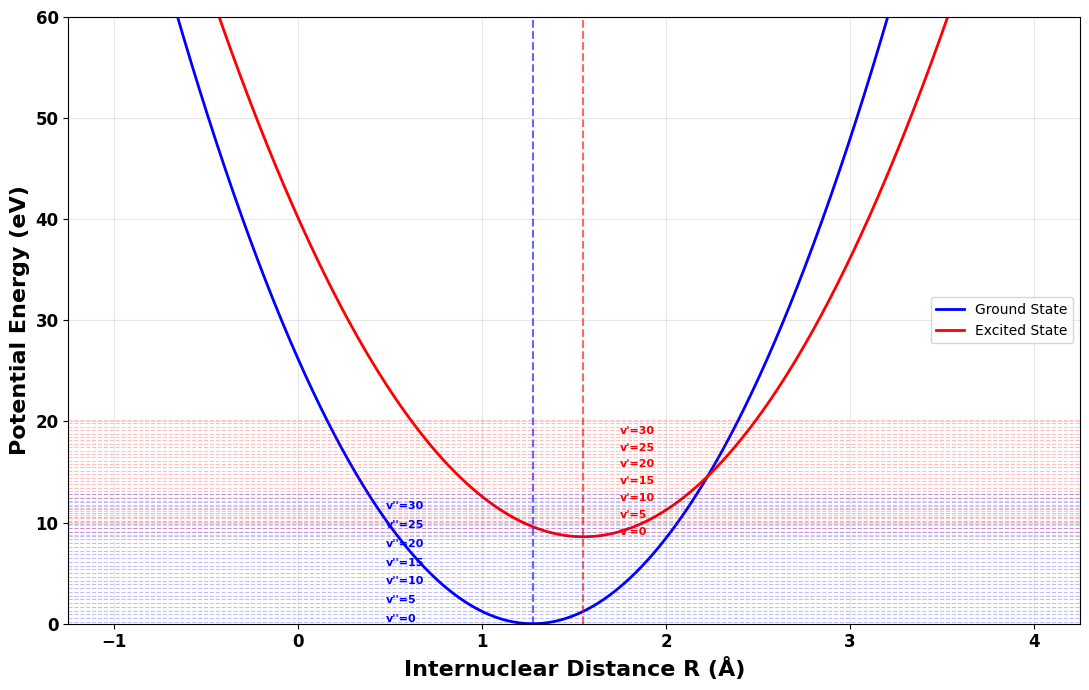

In [ ]:
#HCL (K,eV/Å²)
import numpy as np
import matplotlib.pyplot as plt


class FranckCondonCalculator:
   """
   Franck-Condon diagram for diatomic molecules
   with dynamic plotting and 35 vibrational levels
   """

   def __init__(self, molecule_data):
       self.Re_g = molecule_data['Re_g']
       self.Re_e = molecule_data['Re_e']
       self.k_g = molecule_data['k_g']
       self.k_e = molecule_data['k_e']
       self.mu = molecule_data['mu']
       self.E_e = molecule_data['E_e']

       self._calculate_frequencies()

   def _calculate_frequencies(self):
       # Convert eV/Å² → N/m
       k_g_SI = self.k_g * 16.02176634
       k_e_SI = self.k_e * 16.02176634

       # Angular frequencies
       self.omega_g = np.sqrt(k_g_SI / self.mu)
       self.omega_e = np.sqrt(k_e_SI / self.mu)

       print(f"ωg = {self.omega_g:.2e} rad/s")
       print(f"ωe = {self.omega_e:.2e} rad/s")

   def _compute_vibrational_levels(self):
       max_v = 35

       hbar = 1.054571817e-34
       eV_to_J = 1.602176634e-19

       E_vib_g = [(v + 0.5) * hbar * self.omega_g / eV_to_J for v in range(max_v)]
       E_vib_e = [(v + 0.5) * hbar * self.omega_e / eV_to_J + self.E_e for v in range(max_v)]

       return E_vib_g, E_vib_e, max_v

   def plot_potential_curves_and_levels(self):
       # 🔥 Smart R range (centered around both wells)
       R_min = -1.0
       R_max = 4.0
       R = np.linspace(R_min, R_max, 3000)

       # Potential curves
       V_g = 0.5 * self.k_g * (R - self.Re_g) ** 2
       V_e = self.E_e + 0.5 * self.k_e * (R - self.Re_e) ** 2
       # Ground state minimum (from plotted data)
       min_g_index = np.argmin(V_g)
       print("Ground state minimum:")
       print("R =", R[min_g_index], "Å")
       print("Energy =", V_g[min_g_index], "eV")

       # Excited state minimum
       min_e_index = np.argmin(V_e)
       print("\nExcited state minimum:")
       print("R =", R[min_e_index], "Å")
       print("Energy =", V_e[min_e_index], "eV")
       # Vibrational levels
       E_vib_g, E_vib_e, max_v = self._compute_vibrational_levels()

       plt.figure(figsize=(11, 7))

       # 🔵 Ground, 🔴 Excited
       plt.plot(R, V_g, color='blue', linewidth=2, label='Ground State')
       plt.plot(R, V_e, color='red', linewidth=2, label='Excited State')

       # Equilibrium positions
       plt.axvline(self.Re_g, color='blue', linestyle='--', alpha=0.6)
       plt.axvline(self.Re_e, color='red', linestyle='--', alpha=0.6)

       # Vibrational levels (clean + readable)
       for v in range(max_v):
           plt.axhline(E_vib_g[v], color='blue', linestyle='--', alpha=0.25, linewidth=0.8)
           plt.axhline(E_vib_e[v], color='red', linestyle='--', alpha=0.25, linewidth=0.8)

           # Label every 5th level
           if v % 5 == 0:
               plt.text(self.Re_g - 0.8, E_vib_g[v], f"v''={v}", fontsize=8, weight='bold', color='blue')
               plt.text(self.Re_e + 0.2, E_vib_e[v], f"v'={v}", fontsize=8, weight='bold', color='red')


       plt.ylim(0,60)
       # Labels and styling
       plt.xlabel('Internuclear Distance R (Å)', fontsize=16, weight='bold')
       plt.ylabel('Potential Energy (eV)', fontsize=16, weight='bold')
       plt.xticks(fontsize=12, weight='bold')  # Increase font size for x axis tick marks
       plt.yticks(fontsize=12, weight='bold')  # Increase font size for y axis tick marks
       plt.legend( fontsize=12)  # Add legend for clarity
       from google.colab import drive
       drive.mount('/content/drive')
       plt.savefig('/content/drive/My Drive/Harmonic/Figure 1.jpg', dpi=300)
       plt.grid(alpha=0.3)
       plt.legend()
       plt.tight_layout()
       plt.savefig("HCl_dynamic.png", dpi=300)
       plt.show()


def main():
   hcl_data = {
       'Re_g': 1.274,
       'Re_e': 1.55,
       'k_g': 32.20,
       'k_e': 26.21,
       'mu': 1.626e-27,
       'E_e': 8.6
   }

   print("=" * 40)

   fc_calc = FranckCondonCalculator(hcl_data)
   fc_calc.plot_potential_curves_and_levels()


if __name__ == "__main__":
   main()


Franck-Condon Analysis for HI
ωg = 4.35e+14 rad/s
ωe = 3.88e+14 rad/s
Ground state minimum:
R = 1.6092030676892297 Å
Energy = 4.041175668092018e-07 eV

Excited state minimum:
R = 1.8999666555518502 Å
Energy = 6.200000008672448 eV
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


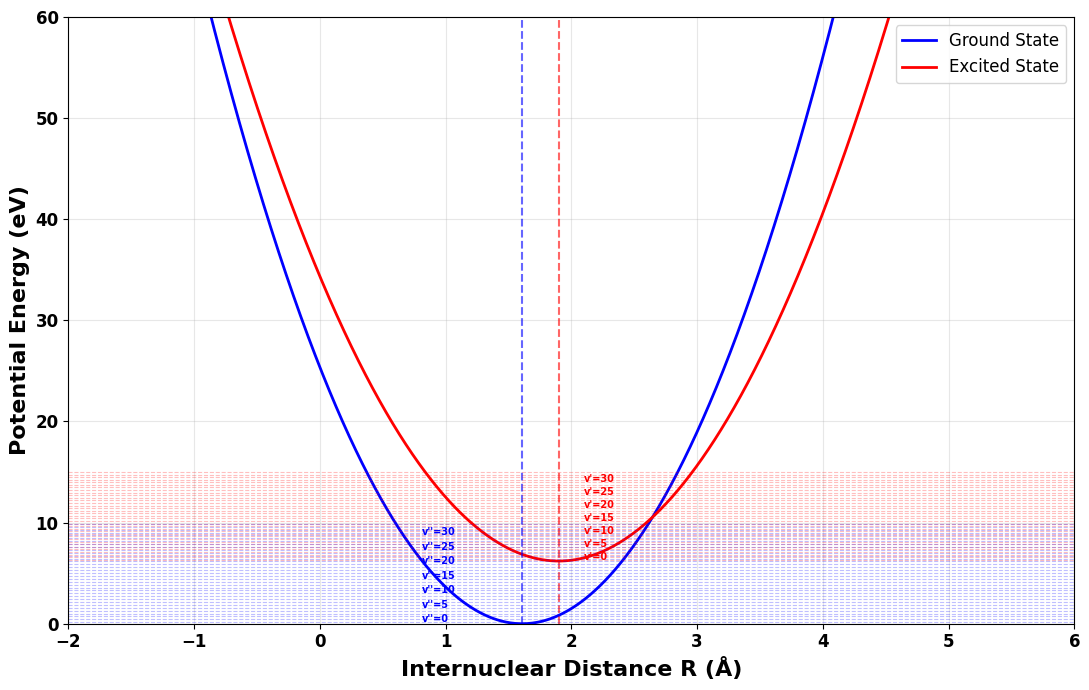

In [ ]:
#HI (K,eV/Å²)
import numpy as np
import matplotlib.pyplot as plt


class FranckCondonCalculator:
   """
   Franck-Condon diagram for HI
   with dynamic scaling and 35 vibrational levels
   """

   def __init__(self, molecule_data):
       self.Re_g = molecule_data['Re_g']
       self.Re_e = molecule_data['Re_e']
       self.k_g = molecule_data['k_g']
       self.k_e = molecule_data['k_e']
       self.mu = molecule_data['mu']
       self.E_e = molecule_data['E_e']

       self._calculate_frequencies()

   def _calculate_frequencies(self):
       k_g_SI = self.k_g * 16.02176634
       k_e_SI = self.k_e * 16.02176634

       self.omega_g = np.sqrt(k_g_SI / self.mu)
       self.omega_e = np.sqrt(k_e_SI / self.mu)

       print(f"ωg = {self.omega_g:.2e} rad/s")
       print(f"ωe = {self.omega_e:.2e} rad/s")

   def _compute_vibrational_levels(self):
       max_v = 35

       hbar = 1.054571817e-34
       eV_to_J = 1.602176634e-19

       E_vib_g = [(v + 0.5) * hbar * self.omega_g / eV_to_J for v in range(max_v)]
       E_vib_e = [(v + 0.5) * hbar * self.omega_e / eV_to_J + self.E_e for v in range(max_v)]

       return E_vib_g, E_vib_e, max_v

   def plot_potential_curves_and_levels(self):
       # 🔥 Centered R range
       R_min = -2.0
       R_max = 6.0
       R = np.linspace(R_min, R_max, 3000)

       # Potential curves
       V_g = 0.5 * self.k_g * (R - self.Re_g) ** 2
       V_e = self.E_e + 0.5 * self.k_e * (R - self.Re_e) ** 2
       # Ground state minimum (from plotted data)
       min_g_index = np.argmin(V_g)
       print("Ground state minimum:")
       print("R =", R[min_g_index], "Å")
       print("Energy =", V_g[min_g_index], "eV")

       # Excited state minimum
       min_e_index = np.argmin(V_e)
       print("\nExcited state minimum:")
       print("R =", R[min_e_index], "Å")
       print("Energy =", V_e[min_e_index], "eV")
       # Vibrational levels
       E_vib_g, E_vib_e, max_v = self._compute_vibrational_levels()

       plt.figure(figsize=(11, 7))

       # 🔵 Ground, 🔴 Excited
       plt.plot(R, V_g, color='blue', linewidth=2, label='Ground State')
       plt.plot(R, V_e, color='red', linewidth=2, label='Excited State')

       # Equilibrium lines
       plt.axvline(self.Re_g, color='blue', linestyle='--', alpha=0.6)
       plt.axvline(self.Re_e, color='red', linestyle='--', alpha=0.6)

       # Vibrational levels
       for v in range(max_v):
           plt.axhline(E_vib_g[v], color='blue', linestyle='--', alpha=0.25, linewidth=0.8)
           plt.axhline(E_vib_e[v], color='red', linestyle='--', alpha=0.25, linewidth=0.8)

           # Label every 5th level
           if v % 5 == 0:
               plt.text(self.Re_g - 0.8, E_vib_g[v], f"v''={v}", fontsize=7, weight='bold', color='blue')
               plt.text(self.Re_e + 0.2, E_vib_e[v], f"v'={v}", fontsize=7, weight='bold', color='red')

       # 🔥 Dynamic Y scaling

       plt.ylim(0,60)

       # Labels
       plt.xlabel('Internuclear Distance R (Å)', fontsize=16, weight='bold')
       plt.ylabel('Potential Energy (eV)', fontsize=16, weight='bold')
       plt.xticks(fontsize=12, weight='bold')  # Increase font size for x axis tick marks
       plt.yticks(fontsize=12, weight='bold')  # Increase font size for y axis tick marks
       from google.colab import drive
       drive.mount('/content/drive')
       plt.savefig('/content/drive/My Drive/Harmonic/Figure 2.jpg', dpi=300)
       plt.xlim(R_min, R_max)
       plt.grid(alpha=0.3)
       plt.legend( fontsize=12)
       plt.tight_layout()
       plt.savefig("HI_dynamic.png", dpi=300)
       plt.show()
def main():
   hi_data = {
       'Re_g': 1.609,
       'Re_e': 1.90,
       'k_g': 19.60,
       'k_e': 15.60,
       'mu': 1.66e-27,
       'E_e': 6.2
   }

   print("Franck-Condon Analysis for HI")
   print("=" * 40)

   fc_calc = FranckCondonCalculator(hi_data)
   fc_calc.plot_potential_curves_and_levels()


if __name__ == "__main__":
   main()


Franck–Condon Analysis (Range: -3 Å to 7 Å)
ωg = 5.00e+14 rad/s
ωe = 4.47e+14 rad/s
Ground state minimum:
R = 1.4141380460153385 Å
Energy = 2.4506919223220195e-07 eV

Excited state minimum:
R = 1.6507169056352118 Å
Energy = 7.500005293723005 eV
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


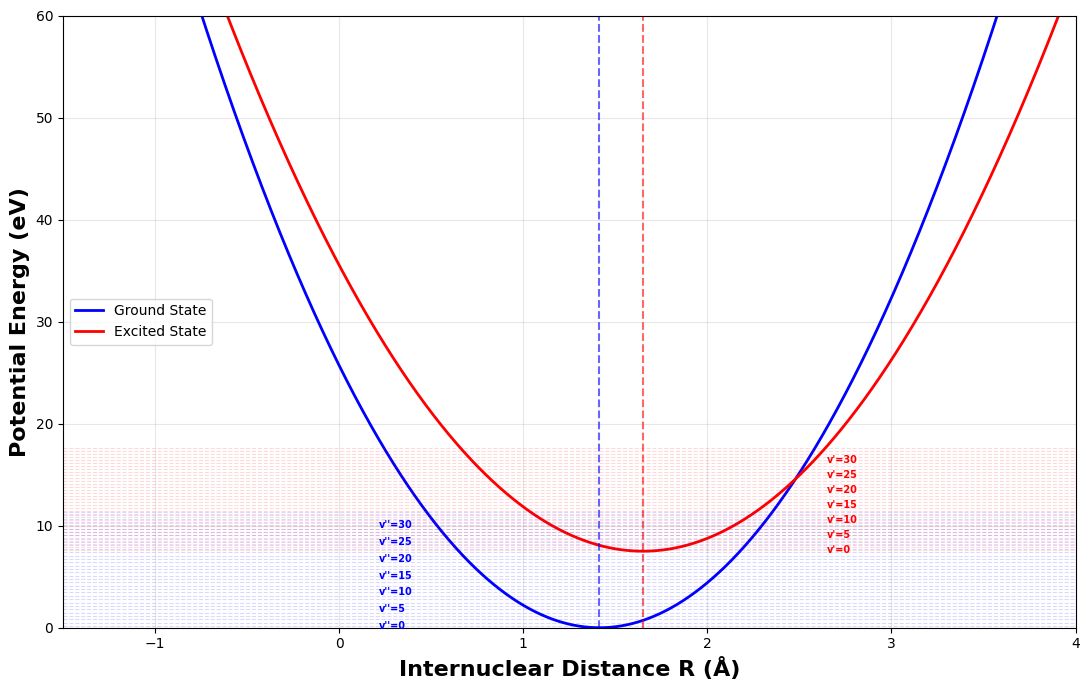

In [ ]:
#HBR (K,eV/Å²)
import numpy as np
import matplotlib.pyplot as plt
class FranckCondonCalculator:
   """
   Franck-Condon diagram for HI
   with dynamic scaling and 35 vibrational levels
   """
   def __init__(self, molecule_data):
       self.Re_g = molecule_data['Re_g']
       self.Re_e = molecule_data['Re_e']
       self.k_g = molecule_data['k_g']
       self.k_e = molecule_data['k_e']
       self.mu = molecule_data['mu']
       self.E_e = molecule_data['E_e']

       self._calculate_frequencies()

   def _calculate_frequencies(self):
       k_g_SI = self.k_g * 16.02176634
       k_e_SI = self.k_e * 16.02176634

       self.omega_g = np.sqrt(k_g_SI / self.mu)
       self.omega_e = np.sqrt(k_e_SI / self.mu)
       print(f"ωg = {self.omega_g:.2e} rad/s")
       print(f"ωe = {self.omega_e:.2e} rad/s")

   def _compute_vibrational_levels(self, max_v=35):
       hbar = 1.054571817e-34
       eV_to_J = 1.602176634e-19

       E_g = [(v + 0.5) * hbar * self.omega_g / eV_to_J for v in range(max_v)]
       E_e = [(v + 0.5) * hbar * self.omega_e / eV_to_J + self.E_e for v in range(max_v)]

       return E_g, E_e, max_v

   def plot(self):
       # 🔥 FINAL RANGE: -3 Å → 7 Å
       R_min = -1.5
       R_max = 4.0
       R = np.linspace(R_min, R_max, 3000)

       # Harmonic potentials
       V_g = 0.5 * self.k_g * (R - self.Re_g) ** 2
       V_e = self.E_e + 0.5 * self.k_e * (R - self.Re_e) ** 2
       # Ground state minimum (from plotted data)
       min_g_index = np.argmin(V_g)
       print("Ground state minimum:")
       print("R =", R[min_g_index], "Å")
       print("Energy =", V_g[min_g_index], "eV")

       # Excited state minimum
       min_e_index = np.argmin(V_e)
       print("\nExcited state minimum:")
       print("R =", R[min_e_index], "Å")
       print("Energy =", V_e[min_e_index], "eV")
       # Vibrational levels
       E_g, E_e, max_v = self._compute_vibrational_levels()

       plt.figure(figsize=(11, 7))

       # Curves
       plt.plot(R, V_g, color='blue', linewidth=2, label='Ground State')
       plt.plot(R, V_e, color='red', linewidth=2, label='Excited State')

       # Equilibrium positions
       plt.axvline(self.Re_g, color='blue', linestyle='--', alpha=0.6)
       plt.axvline(self.Re_e, color='red', linestyle='--', alpha=0.6)

       # Vibrational levels
       for v in range(max_v):
           plt.axhline(E_g[v], color='blue', linestyle='--', alpha=0.15, linewidth=0.8)
           plt.axhline(E_e[v], color='red', linestyle='--', alpha=0.15, linewidth=0.8)

           if v % 5 == 0:
               # Ground state labels
               plt.text(self.Re_g - 1.2, E_g[v], f"v''={v}",
                        fontsize=7, weight='bold', color='blue', va='center')
               # Excited state labels
               plt.text(self.Re_e + 1.0, E_e[v], f"v'={v}",
                        fontsize=7, weight='bold', color='red', va='center')

       # Control vertical scaling
       plt.ylim(0, 60)
       plt.xlim(-1.5, 4)
       # 🔥 FORCE FULL RANGE
       # Labels and title
       plt.xlabel('Internuclear Distance R (Å)', fontsize=16, weight='bold')
       plt.ylabel('Potential Energy (eV)', fontsize=16, weight='bold')
       from google.colab import drive
       drive.mount('/content/drive')
       plt.savefig('/content/drive/My Drive/Harmonic/Figure 2.jpg', dpi=300)
       plt.grid(alpha=0.3)
       plt.legend()
       plt.tight_layout()
       plt.show()

def main():
   hbr_data = {
       'Re_g': 1.414,
       'Re_e': 1.65,
       'k_g': 25.72,
       'k_e': 20.60,
       'mu': 1.65e-27,
       'E_e': 7.5
   }

   print("Franck–Condon Analysis (Range: -3 Å to 7 Å)")
   print("=" * 50)

   fc = FranckCondonCalculator(hbr_data)
   fc.plot()


if __name__ == "__main__":
   main()


Franck-Condon Analysis for HF
ωg = 7.79e+14 rad/s
ωe = 6.87e+14 rad/s
Ground state minimum:
R = 0.9166388796265421 Å
Energy = 3.931146872790038e-06 eV

Excited state minimum:
R = 1.1500500166722238 Å
Energy = 11.000000058551528 eV
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


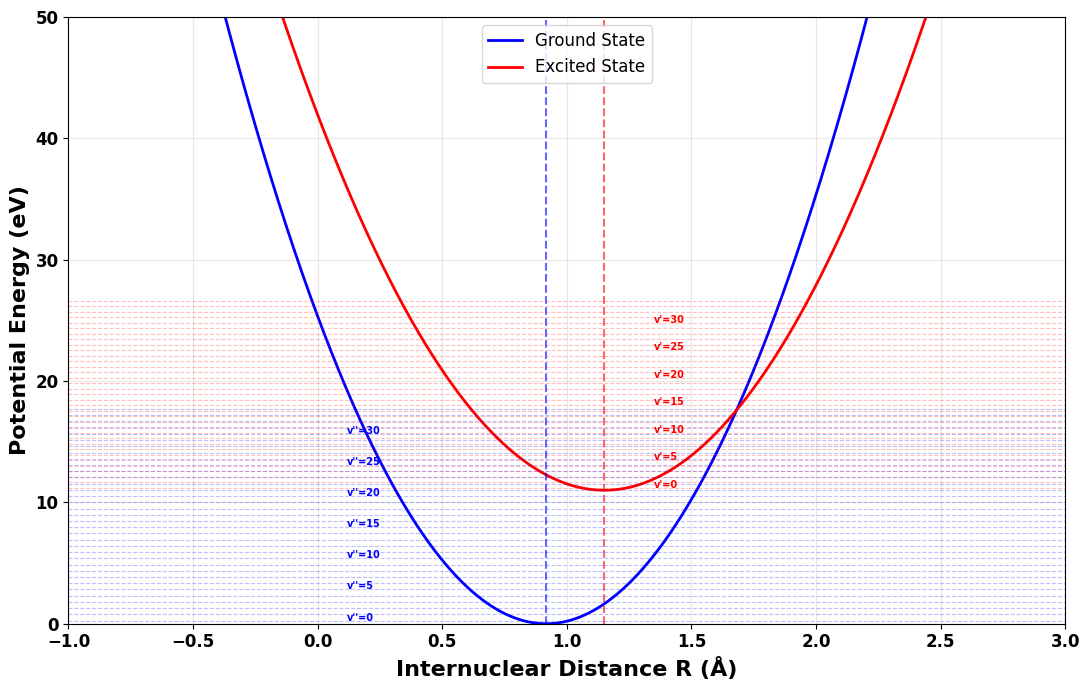

In [ ]:
#HF (K,eV/Å²)
import numpy as np
import matplotlib.pyplot as plt


class FranckCondonCalculator:
   """
   Franck-Condon diagram for diatomic molecules
   with dynamic scaling and 35 vibrational levels
   """

   def __init__(self, molecule_data):
       self.Re_g = molecule_data['Re_g']
       self.Re_e = molecule_data['Re_e']
       self.k_g = molecule_data['k_g']
       self.k_e = molecule_data['k_e']
       self.mu = molecule_data['mu']
       self.E_e = molecule_data['E_e']

       self._calculate_frequencies()

   def _calculate_frequencies(self):
       k_g_SI = self.k_g * 16.02176634
       k_e_SI = self.k_e * 16.02176634

       self.omega_g = np.sqrt(k_g_SI / self.mu)
       self.omega_e = np.sqrt(k_e_SI / self.mu)

       print(f"ωg = {self.omega_g:.2e} rad/s")
       print(f"ωe = {self.omega_e:.2e} rad/s")

   def _compute_vibrational_levels(self):
       max_v = 35

       hbar = 1.054571817e-34
       eV_to_J = 1.602176634e-19

       E_vib_g = [(v + 0.5) * hbar * self.omega_g / eV_to_J for v in range(max_v)]
       E_vib_e = [(v + 0.5) * hbar * self.omega_e / eV_to_J + self.E_e for v in range(max_v)]

       return E_vib_g, E_vib_e, max_v

   def plot_potential_curves_and_levels(self):
       # 🔥 Centered R range
       R_min = -1.0
       R_max = 3.0
       R = np.linspace(R_min, R_max, 3000)

       # Potential curves
       V_g = 0.5 * self.k_g * (R - self.Re_g) ** 2
       V_e = self.E_e + 0.5 * self.k_e * (R - self.Re_e) ** 2
       # Ground state minimum (from plotted data)
       min_g_index = np.argmin(V_g)
       print("Ground state minimum:")
       print("R =", R[min_g_index], "Å")
       print("Energy =", V_g[min_g_index], "eV")

       # Excited state minimum
       min_e_index = np.argmin(V_e)
       print("\nExcited state minimum:")
       print("R =", R[min_e_index], "Å")
       print("Energy =", V_e[min_e_index], "eV")
       # Vibrational levels
       E_vib_g, E_vib_e, max_v = self._compute_vibrational_levels()

       plt.figure(figsize=(11, 7))

       # 🔵 Ground, 🔴 Excited
       plt.plot(R, V_g, color='blue', linewidth=2, label='Ground State')
       plt.plot(R, V_e, color='red', linewidth=2, label='Excited State')

       # Equilibrium positions
       plt.axvline(self.Re_g, color='blue', linestyle='--', alpha=0.6)
       plt.axvline(self.Re_e, color='red', linestyle='--', alpha=0.6)

       # Vibrational levels
       for v in range(max_v):
           plt.axhline(E_vib_g[v], color='blue', linestyle='--', alpha=0.25, linewidth=0.8)
           plt.axhline(E_vib_e[v], color='red', linestyle='--', alpha=0.25, linewidth=0.8)

           # Label every 5th level
           if v % 5 == 0:
               plt.text(self.Re_g - 0.8, E_vib_g[v], f"v''={v}", fontsize=7, weight='bold', color='blue')
               plt.text(self.Re_e + 0.2, E_vib_e[v], f"v'={v}", fontsize=7, weight='bold', color='red')

       # 🔥 Dynamic Y scaling (correct way)

       plt.ylim(0,50)
       plt.xlim(R_min, R_max)
       # Labels
       plt.xlabel('Internuclear Distance R (Å)', fontsize=16, weight='bold')
       plt.ylabel('Potential Energy (eV)', fontsize=16, weight='bold')
       plt.xticks(fontsize=12, weight='bold')  # Increase font size for x axis tick marks
       plt.yticks(fontsize=12, weight='bold')  # Increase font size for y axis tick marks
       from google.colab import drive
       drive.mount('/content/drive')
       plt.savefig('/content/drive/My Drive/Harmonic/Figure 4.jpg', dpi=300)
       plt.grid(alpha=0.3)
       plt.legend( fontsize=12)
       plt.tight_layout()
       plt.show()

def main():
   hf_data = {
       'Re_g': 0.917,
       'Re_e': 1.15,
       'k_g': 60.29,
       'k_e': 46.81,
       'mu': 1.59e-27,
       'E_e': 11.0
   }

   print("Franck-Condon Analysis for HF")
   print("=" * 40)

   fc_calc = FranckCondonCalculator(hf_data)
   fc_calc.plot_potential_curves_and_levels()


if __name__ == "__main__":
   main()


Franck-Condon Analysis for NITROGEN
ωg = 4.45e+14 rad/s
ωe = 3.71e+14 rad/s
Ground state minimum:
R = 1.0978659553184396 Å
Energy = 1.2880344064895824e-06 eV

Excited state minimum:
R = 1.2795931977325776 Å
Energy = 7.400008262820074 eV
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


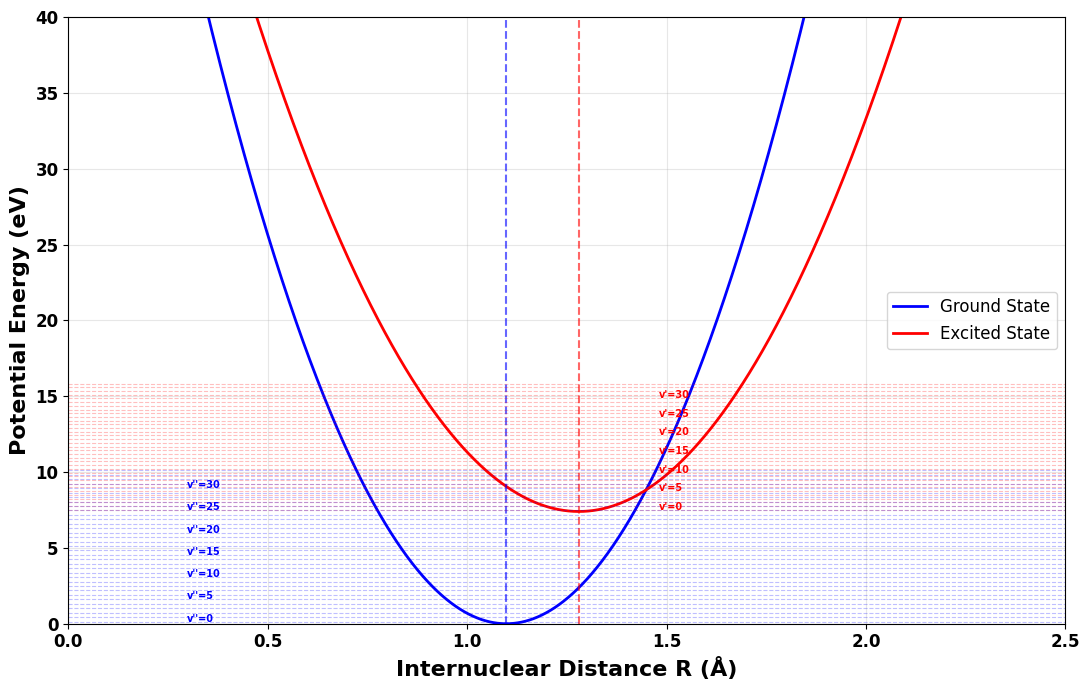

In [ ]:
#NITROGEN (K,eV/Å²)
import numpy as np
import matplotlib.pyplot as plt


class FranckCondonCalculator:
   """
   Franck-Condon diagram for N2
   with dynamic scaling and 35 vibrational levels
   """

   def __init__(self, molecule_data):
       self.Re_g = molecule_data['Re_g']
       self.Re_e = molecule_data['Re_e']
       self.k_g = molecule_data['k_g']
       self.k_e = molecule_data['k_e']
       self.mu = molecule_data['mu']
       self.E_e = molecule_data['E_e']

       self._calculate_frequencies()

   def _calculate_frequencies(self):
       k_g_SI = self.k_g * 16.02176634
       k_e_SI = self.k_e * 16.02176634

       self.omega_g = np.sqrt(k_g_SI / self.mu)
       self.omega_e = np.sqrt(k_e_SI / self.mu)

       print(f"ωg = {self.omega_g:.2e} rad/s")
       print(f"ωe = {self.omega_e:.2e} rad/s")

   def _compute_vibrational_levels(self):
       max_v = 35

       hbar = 1.054571817e-34
       eV_to_J = 1.602176634e-19

       E_vib_g = [(v + 0.5) * hbar * self.omega_g / eV_to_J for v in range(max_v)]
       E_vib_e = [(v + 0.5) * hbar * self.omega_e / eV_to_J + self.E_e for v in range(max_v)]

       return E_vib_g, E_vib_e, max_v

   def plot_potential_curves_and_levels(self):
       # 🔥 Centered R range
       R_min = 0.0
       R_max = 2.5
       R = np.linspace(R_min, R_max, 3000)

       # Potential curves
       V_g = 0.5 * self.k_g * (R - self.Re_g) ** 2
       V_e = self.E_e + 0.5 * self.k_e * (R - self.Re_e) ** 2
       # Ground state minimum (from plotted data)
       min_g_index = np.argmin(V_g)
       print("Ground state minimum:")
       print("R =", R[min_g_index], "Å")
       print("Energy =", V_g[min_g_index], "eV")

       # Excited state minimum
       min_e_index = np.argmin(V_e)
       print("\nExcited state minimum:")
       print("R =", R[min_e_index], "Å")
       print("Energy =", V_e[min_e_index], "eV")
       # Vibrational levels
       E_vib_g, E_vib_e, max_v = self._compute_vibrational_levels()

       plt.figure(figsize=(11, 7))

       # 🔵 Ground, 🔴 Excited
       plt.plot(R, V_g, color='blue', linewidth=2, label='Ground State')
       plt.plot(R, V_e, color='red', linewidth=2, label='Excited State')

       # Equilibrium lines
       plt.axvline(self.Re_g, color='blue', linestyle='--', alpha=0.6)
       plt.axvline(self.Re_e, color='red', linestyle='--', alpha=0.6)

       # Vibrational levels
       for v in range(max_v):
           plt.axhline(E_vib_g[v], color='blue', linestyle='--', alpha=0.25, linewidth=0.8)
           plt.axhline(E_vib_e[v], color='red', linestyle='--', alpha=0.25, linewidth=0.8)

           # Label every 5th level
           if v % 5 == 0:
               plt.text(self.Re_g - 0.8, E_vib_g[v], f"v''={v}", fontsize=7,  weight='bold', color='blue')
               plt.text(self.Re_e + 0.2, E_vib_e[v], f"v'={v}", fontsize=7, weight='bold', color='red')

       # 🔥 Dynamic Y scaling (fixes your main issue)

       plt.ylim(0,40)

       # Labels
       plt.xlabel('Internuclear Distance R (Å)', fontsize=16, weight='bold')
       plt.ylabel('Potential Energy (eV)', fontsize=16, weight='bold')
       plt.xticks(fontsize=12, weight='bold')  # Increase font size for x axis tick marks
       plt.yticks(fontsize=12, weight='bold')  # Increase font size for y axis tick marks
       from google.colab import drive
       drive.mount('/content/drive')
       plt.savefig('/content/drive/My Drive/Harmonic/Figure 5.jpg', dpi=300)
       plt.xlim(R_min, R_max)
       plt.grid(alpha=0.3)
       plt.grid(alpha=0.3)
       plt.legend( fontsize=12)
       plt.tight_layout()
       plt.show()

def main():
   N2_data = {
       'Re_g': 1.098,
       'Re_e': 1.28,
       'k_g': 143.37,
       'k_e': 99.86,
       'mu': 1.16e-26,
       'E_e': 7.4
   }

   print("Franck-Condon Analysis for NITROGEN")
   print("=" * 40)

   fc_calc = FranckCondonCalculator(N2_data)
   fc_calc.plot_potential_curves_and_levels()


if __name__ == "__main__":
   main()


Franck-Condon Analysis for OXYGEN
ωg = 2.97e+14 rad/s
ωe = 2.53e+14 rad/s
Ground state minimum:
R = 1.2074024674891632 Å
Energy = 5.948313481678648e-06 eV

Excited state minimum:
R = 1.3101033677892633 Å
Energy = 6.200000283416969 eV
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


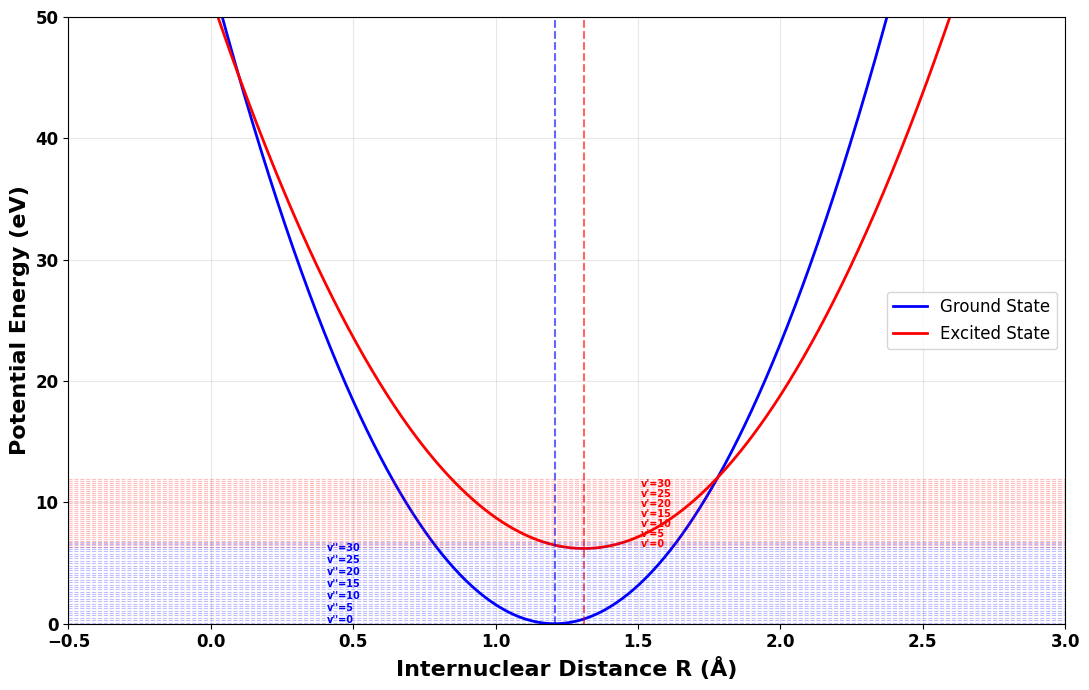

In [ ]:
#O2 (K,eV/Å²)
import numpy as np
import matplotlib.pyplot as plt


class FranckCondonCalculator:
   """
   Franck-Condon diagram for O2
   with dynamic scaling and 35 vibrational levels
   """

   def __init__(self, molecule_data):
       self.Re_g = molecule_data['Re_g']
       self.Re_e = molecule_data['Re_e']
       self.k_g = molecule_data['k_g']
       self.k_e = molecule_data['k_e']
       self.mu = molecule_data['mu']
       self.E_e = molecule_data['E_e']

       self._calculate_frequencies()

   def _calculate_frequencies(self):
       k_g_SI = self.k_g * 16.02176634
       k_e_SI = self.k_e * 16.02176634

       self.omega_g = np.sqrt(k_g_SI / self.mu)
       self.omega_e = np.sqrt(k_e_SI / self.mu)

       print(f"ωg = {self.omega_g:.2e} rad/s")
       print(f"ωe = {self.omega_e:.2e} rad/s")

   def _compute_vibrational_levels(self):
       max_v = 35

       hbar = 1.054571817e-34
       eV_to_J = 1.602176634e-19

       E_vib_g = [(v + 0.5) * hbar * self.omega_g / eV_to_J for v in range(max_v)]
       E_vib_e = [(v + 0.5) * hbar * self.omega_e / eV_to_J + self.E_e for v in range(max_v)]

       return E_vib_g, E_vib_e, max_v

   def plot_potential_curves_and_levels(self):
       # 🔥 Centered R range
       R_min = -0.5
       R_max = 3.0
       R = np.linspace(R_min, R_max, 3000)

       # Potential curves
       V_g = 0.5 * self.k_g * (R - self.Re_g) ** 2
       V_e = self.E_e + 0.5 * self.k_e * (R - self.Re_e) ** 2

       # Ground state minimum (from plotted data)
       min_g_index = np.argmin(V_g)
       print("Ground state minimum:")
       print("R =", R[min_g_index], "Å")
       print("Energy =", V_g[min_g_index], "eV")

       # Excited state minimum
       min_e_index = np.argmin(V_e)
       print("\nExcited state minimum:")
       print("R =", R[min_e_index], "Å")
       print("Energy =", V_e[min_e_index], "eV")

       # Vibrational levels
       E_vib_g, E_vib_e, max_v = self._compute_vibrational_levels()

       plt.figure(figsize=(11, 7))

       # 🔵 Ground, 🔴 Excited
       plt.plot(R, V_g, color='blue', linewidth=2, label='Ground State')
       plt.plot(R, V_e, color='red', linewidth=2, label='Excited State')

       # Equilibrium lines
       plt.axvline(self.Re_g, color='blue', linestyle='--', alpha=0.6)
       plt.axvline(self.Re_e, color='red', linestyle='--', alpha=0.6)

       # Vibrational levels
       for v in range(max_v):
           plt.axhline(E_vib_g[v], color='blue', linestyle='--', alpha=0.25, linewidth=0.8)
           plt.axhline(E_vib_e[v], color='red', linestyle='--', alpha=0.25, linewidth=0.8)

           # Label every 5th level
           if v % 5 == 0:
               plt.text(self.Re_g - 0.8, E_vib_g[v], f"v''={v}", fontsize=7, weight='bold', color='blue')
               plt.text(self.Re_e + 0.2, E_vib_e[v], f"v'={v}", fontsize=7, weight='bold', color='red')

       # 🔥 Dynamic Y scaling

       plt.ylim(0,50)

       # Labels
       plt.xlabel('Internuclear Distance R (Å)', fontsize=16, weight='bold')
       plt.ylabel('Potential Energy (eV)', fontsize=16, weight='bold')
       plt.xticks(fontsize=12, weight='bold')  # Increase font size for x axis tick marks
       plt.yticks(fontsize=12, weight='bold')  # Increase font size for y axis tick marks
       from google.colab import drive
       drive.mount('/content/drive')
       plt.savefig('/content/drive/My Drive/Harmonic/Figure 6.jpg', dpi=300)
       plt.xlim(R_min, R_max)
       plt.grid(alpha=0.3)
       plt.legend( fontsize=12)
       plt.tight_layout()
       plt.savefig("O2_dynamic.png", dpi=300)
       plt.show()
def main():
   O2_data = {
       'Re_g': 1.207,
       'Re_e': 1.31,
       'k_g': 73.445,
       'k_e': 53.05,
       'mu': 1.33e-26,
       'E_e': 6.2
   }

   print("Franck-Condon Analysis for OXYGEN")
   print("=" * 40)

   fc_calc = FranckCondonCalculator(O2_data)
   fc_calc.plot_potential_curves_and_levels()


if __name__ == "__main__":
   main()


Franck-Condon Analysis for CHLORINE
ωg = 1.06e+14 rad/s
ωe = 9.22e+13 rad/s
Ground state minimum:
R = 1.988323603002502 Å
Energy = 1.7904672562131337e-05 eV

Excited state minimum:
R = 2.1984987489574643 Å
Energy = 3.6000175792866034 eV
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


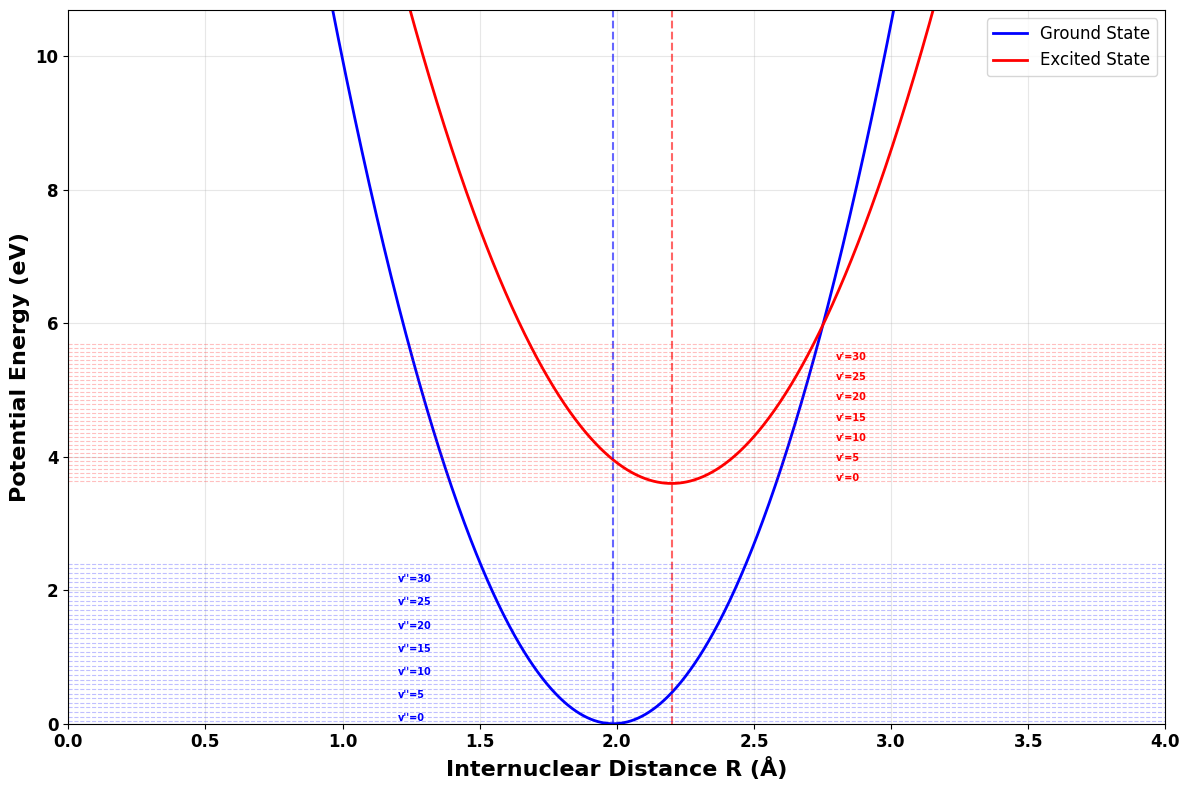

In [ ]:
#CHLORINE(K,eV/Å²)
import numpy as np
import matplotlib.pyplot as plt


class FranckCondonCalculator:
   def __init__(self, molecule_data):
       self.Re_g = molecule_data['Re_g']
       self.Re_e = molecule_data['Re_e']
       self.k_g = molecule_data['k_g']
       self.k_e = molecule_data['k_e']
       self.mu = molecule_data['mu']
       self.E_e = molecule_data['E_e']

       self._calculate_frequencies()

   def _calculate_frequencies(self):
       k_g_SI = self.k_g * 16.02176634
       k_e_SI = self.k_e * 16.02176634

       self.omega_g = np.sqrt(k_g_SI / self.mu)
       self.omega_e = np.sqrt(k_e_SI / self.mu)

       print(f"ωg = {self.omega_g:.2e} rad/s")
       print(f"ωe = {self.omega_e:.2e} rad/s")

   def _compute_vibrational_levels(self):
       """Fixed to 35 levels"""
       max_v = 35

       hbar = 1.054571817e-34
       eV_to_J = 1.602176634e-19

       E_vib_g = [(v + 0.5) * hbar * self.omega_g / eV_to_J for v in range(max_v)]
       E_vib_e = [(v + 0.5) * hbar * self.omega_e / eV_to_J + self.E_e for v in range(max_v)]

       return E_vib_g, E_vib_e, max_v

   def plot_potential_curves_and_levels(self):
       R = np.linspace(0, 4, 1200)

       V_g = 0.5 * self.k_g * (R - self.Re_g) ** 2
       V_e = self.E_e + 0.5 * self.k_e * (R - self.Re_e) ** 2
       min_g_index = np.argmin(V_g)
       print("Ground state minimum:")
       print("R =", R[min_g_index], "Å")
       print("Energy =", V_g[min_g_index], "eV")

       # Excited state minimum
       min_e_index = np.argmin(V_e)
       print("\nExcited state minimum:")
       print("R =", R[min_e_index], "Å")
       print("Energy =", V_e[min_e_index], "eV")
       E_vib_g, E_vib_e, max_v = self._compute_vibrational_levels()

       plt.figure(figsize=(12, 8))

       # 🔵 Ground (Blue), 🔴 Excited (Red)
       plt.plot(R, V_g, 'b-', linewidth=2, label='Ground State')
       plt.plot(R, V_e, 'r-', linewidth=2, label='Excited State')

       # Equilibrium lines
       plt.axvline(self.Re_g, color='blue', linestyle='--', alpha=0.6)
       plt.axvline(self.Re_e, color='red', linestyle='--', alpha=0.6)

       # Vibrational levels (35)
       for v in range(max_v):
           plt.axhline(E_vib_g[v], color='blue', linestyle='--', alpha=0.25, linewidth=0.8)
           plt.axhline(E_vib_e[v], color='red', linestyle='--', alpha=0.25, linewidth=0.8)

           if v % 5 == 0:
               plt.text(1.2, E_vib_g[v], f"v''={v}", fontsize=7, weight='bold', color='blue')
               plt.text(2.8, E_vib_e[v], f"v'={v}", fontsize=7, weight='bold', color='red')

       # Dynamic Y scaling
       max_energy = max(max(E_vib_g), max(E_vib_e))
       plt.ylim(0, max_energy + 5)

       plt.xlabel('Internuclear Distance R (Å)', fontsize=16, weight='bold')
       plt.ylabel('Potential Energy (eV)', fontsize=16, weight='bold')
       plt.xticks(fontsize=12, weight='bold')  # Increase font size for x axis tick marks
       plt.yticks(fontsize=12, weight='bold')  # Increase font size for y axis tick marksplt.legend()
       from google.colab import drive
       drive.mount('/content/drive')
       plt.savefig('/content/drive/My Drive/Harmonic/Figure 7.jpg', dpi=300)
       plt.grid(alpha=0.3)
       plt.xlim(0, 4)
       plt.legend( fontsize=12)
       plt.tight_layout()
       plt.show()


def main():
   CL2_data = {
       'Re_g': 1.987,
       'Re_e': 2.20,
       'k_g': 20.44,
       'k_e': 15.60,
       'mu': 2.94e-26,
       'E_e': 3.6
   }

   print("Franck-Condon Analysis for CHLORINE")
   print("=" * 40)

   fc_calc = FranckCondonCalculator(CL2_data)

   # ✅ Fixed 35 levels
   fc_calc.plot_potential_curves_and_levels()


if __name__ == "__main__":
   main()


Franck-Condon Analysis for BROMINE
ωg = 6.09e+13 rad/s
ωe = 5.35e+13 rad/s
Ground state minimum:
R = 2.281067556296914 Å
Energy = 3.4981935182098e-08 eV

Excited state minimum:
R = 2.5479566305254377 Å
Energy = 2.700024759877741 eV
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


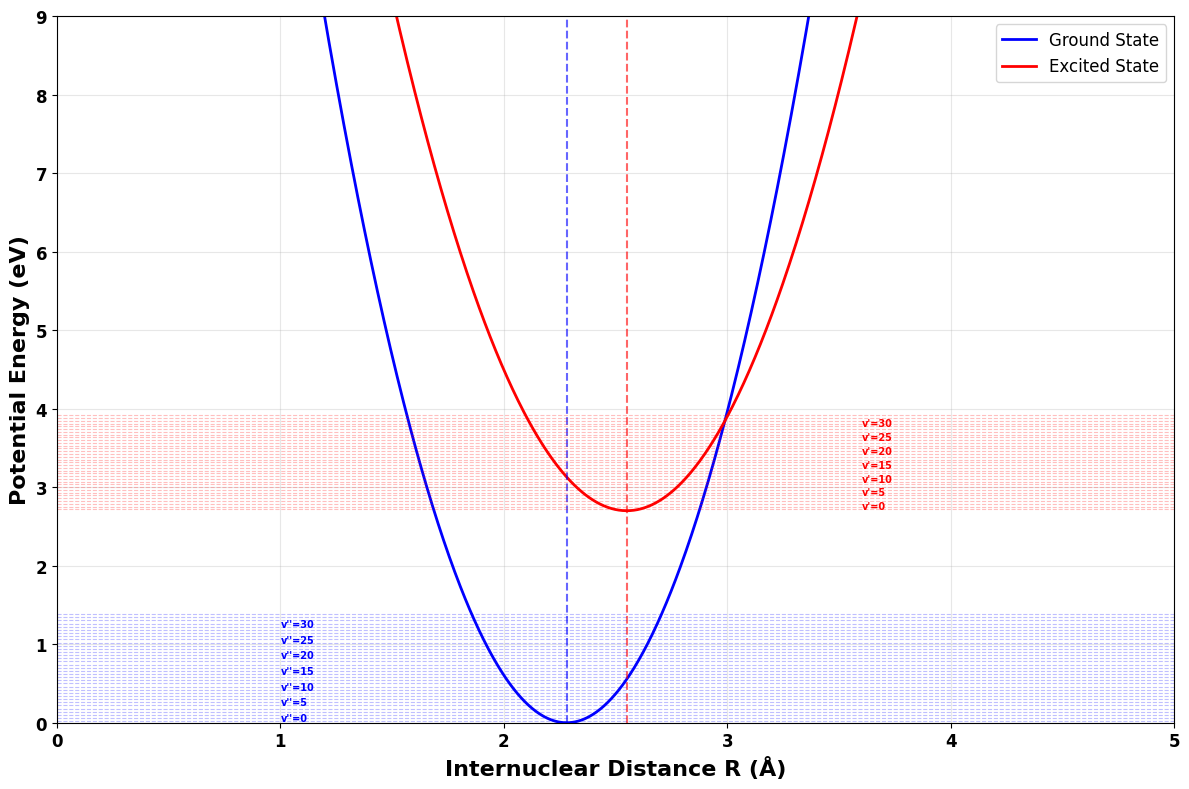

In [ ]:
#BROMINE (K,eV/Å²)
import numpy as np
import matplotlib.pyplot as plt
class FranckCondonCalculator:
   def __init__(self, molecule_data):
       self.Re_g = molecule_data['Re_g']
       self.Re_e = molecule_data['Re_e']
       self.k_g = molecule_data['k_g']
       self.k_e = molecule_data['k_e']
       self.mu = molecule_data['mu']
       self.E_e = molecule_data['E_e']

       self._calculate_frequencies()

   def _calculate_frequencies(self):
       k_g_SI = self.k_g * 16.02176634
       k_e_SI = self.k_e * 16.02176634

       self.omega_g = np.sqrt(k_g_SI / self.mu)
       self.omega_e = np.sqrt(k_e_SI / self.mu)

       print(f"ωg = {self.omega_g:.2e} rad/s")
       print(f"ωe = {self.omega_e:.2e} rad/s")

   def _compute_vibrational_levels(self):
       """Fixed to 35 levels"""
       max_v = 35

       hbar = 1.054571817e-34
       eV_to_J = 1.602176634e-19

       E_vib_g = [(v + 0.5) * hbar * self.omega_g / eV_to_J for v in range(max_v)]
       E_vib_e = [(v + 0.5) * hbar * self.omega_e / eV_to_J + self.E_e for v in range(max_v)]

       return E_vib_g, E_vib_e, max_v

   def plot_potential_curves_and_levels(self):
       R = np.linspace(0, 5, 1200)

       V_g = 0.5 * self.k_g * (R - self.Re_g) ** 2
       V_e = self.E_e + 0.5 * self.k_e * (R - self.Re_e) ** 2
       min_g_index = np.argmin(V_g)
       print("Ground state minimum:")
       print("R =", R[min_g_index], "Å")
       print("Energy =", V_g[min_g_index], "eV")

       # Excited state minimum
       min_e_index = np.argmin(V_e)
       print("\nExcited state minimum:")
       print("R =", R[min_e_index], "Å")
       print("Energy =", V_e[min_e_index], "eV")
       E_vib_g, E_vib_e, max_v = self._compute_vibrational_levels()

       plt.figure(figsize=(12, 8))

       # 🔵 Ground (Blue), 🔴 Excited (Red)
       plt.plot(R, V_g, 'b-', linewidth=2, label='Ground State')
       plt.plot(R, V_e, 'r-', linewidth=2, label='Excited State')

       # Equilibrium lines
       plt.axvline(self.Re_g, color='blue', linestyle='--', alpha=0.6)
       plt.axvline(self.Re_e, color='red', linestyle='--', alpha=0.6)

       # Vibrational levels (35)
       for v in range(max_v):
           plt.axhline(E_vib_g[v], color='blue', linestyle='--', alpha=0.25, linewidth=0.8)
           plt.axhline(E_vib_e[v], color='red', linestyle='--', alpha=0.25, linewidth=0.8)

           if v % 5 == 0:
               plt.text(1.0, E_vib_g[v], f"v''={v}", fontsize=7, weight='bold', color='blue')
               plt.text(3.6, E_vib_e[v], f"v'={v}", fontsize=7, weight='bold', color='red')

       # Dynamic Y scaling
       max_energy = max(max(E_vib_g), max(E_vib_e))
       plt.ylim(0, 9)
       plt.xlim(0,5 )

       plt.xlabel('Internuclear Distance R (Å)', fontsize=16, weight='bold')
       plt.ylabel('Potential Energy (eV)', fontsize=16, weight='bold')
       plt.xticks(fontsize=12, weight='bold')  # Increase font size for x axis tick marks
       plt.yticks(fontsize=12, weight='bold')  # Increase font size for y axis tick marksplt.legend()
       from google.colab import drive
       drive.mount('/content/drive')
       plt.savefig('/content/drive/My Drive/Harmonic/Figure 7.jpg', dpi=300)
       plt.grid(alpha=0.3)
       plt.legend( fontsize=12)
       plt.tight_layout()
       plt.show()


def main():
   BR2_data = {
       'Re_g': 2.281,
       'Re_e': 2.55,
       'k_g': 15.330,
       'k_e': 11.86,
       'mu': 6.63e-26,
       'E_e': 2.7
   }

   print("Franck-Condon Analysis for BROMINE")
   print("=" * 40)

   fc_calc = FranckCondonCalculator(BR2_data)

   # ✅ Fixed 35 levels
   fc_calc.plot_potential_curves_and_levels()


if __name__ == "__main__":
   main()


Franck-Condon Analysis for CO
ωg = 4.04e+14 rad/s
ωe = 3.44e+14 rad/s
Ground state minimum:
R = 1.128023352793995 Å
Energy = 3.165501415209539e-08 eV

Excited state minimum:
R = 1.21976647206005 Å
Energy = 8.200002297572135 eV
Mounted at /content/drive


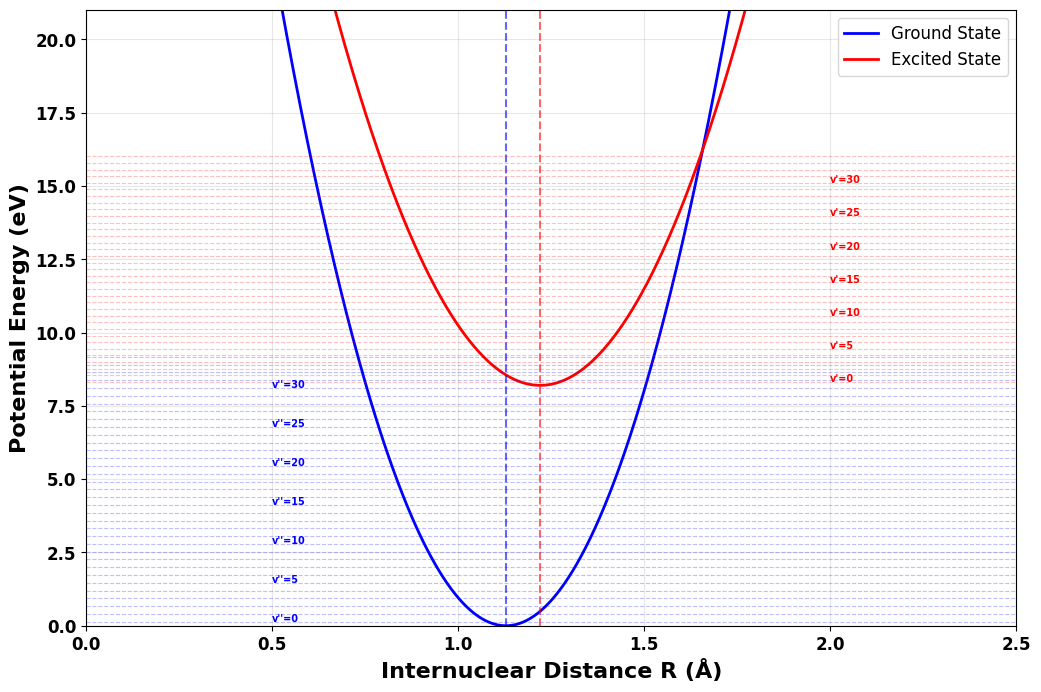

In [ ]:
#CO (K,eV/Å²)
import numpy as np
import matplotlib.pyplot as plt


class PotentialEnergyPlotter:
   def __init__(self, molecule_data):
       self.Re_g = molecule_data['Re_g']
       self.Re_e = molecule_data['Re_e']
       self.k_g = molecule_data['k_g']
       self.k_e = molecule_data['k_e']
       self.mu = molecule_data['mu']
       self.E_e = molecule_data['E_e']

       self._calculate_frequencies()

   def _calculate_frequencies(self):
       k_g_SI = self.k_g * 16.02176634
       k_e_SI = self.k_e * 16.02176634

       self.omega_g = np.sqrt(k_g_SI / self.mu)
       self.omega_e = np.sqrt(k_e_SI / self.mu)
       print(f"ωg = {self.omega_g:.2e} rad/s")
       print(f"ωe = {self.omega_e:.2e} rad/s")
   def _compute_vibrational_levels(self):
       """Fixed to 35 levels"""
       max_v = 35

       hbar = 1.054571817e-34
       eV_to_J = 1.602176634e-19

       E_vib_g = [(v + 0.5) * hbar * self.omega_g / eV_to_J for v in range(max_v)]
       E_vib_e = [(v + 0.5) * hbar * self.omega_e / eV_to_J + self.E_e for v in range(max_v)]

       return E_vib_g, E_vib_e, max_v

   def plot_potential_curves_and_levels(self):
       R = np.linspace(0, 2.5, 1200)

       # Potential curves
       V_g = 0.5 * self.k_g * (R - self.Re_g) ** 2
       V_e = self.E_e + 0.5 * self.k_e * (R - self.Re_e) ** 2

       # Ground state minimum (from plotted data)
       min_g_index = np.argmin(V_g)
       print("Ground state minimum:")
       print("R =", R[min_g_index], "Å")
       print("Energy =", V_g[min_g_index], "eV")

       # Excited state minimum
       min_e_index = np.argmin(V_e)
       print("\nExcited state minimum:")
       print("R =", R[min_e_index], "Å")
       print("Energy =", V_e[min_e_index], "eV")

       # Vibrational levels
       E_vib_g, E_vib_e, max_v = self._compute_vibrational_levels()

       plt.figure(figsize=(12, 8))

       # 🔵 Ground, 🔴 Excited
       plt.plot(R, V_g, 'b-', linewidth=2, label='Ground State')
       plt.plot(R, V_e, 'r-', linewidth=2, label='Excited State')

       # Equilibrium lines
       plt.axvline(self.Re_g, color='blue', linestyle='--', alpha=0.6)
       plt.axvline(self.Re_e, color='red', linestyle='--', alpha=0.6)

       # Vibrational levels (35)
       for v in range(max_v):
           plt.axhline(E_vib_g[v], color='blue', linestyle='--', alpha=0.25, linewidth=0.8)
           plt.axhline(E_vib_e[v], color='red', linestyle='--', alpha=0.25, linewidth=0.8)

           if v % 5 == 0:
               plt.text(0.5, E_vib_g[v], f"v''={v}", fontsize=7, weight='bold', color='blue')
               plt.text(2.0, E_vib_e[v], f"v'={v}", fontsize=7, weight='bold', color='red')

       # Dynamic Y scaling
       max_energy = max(max(E_vib_g), max(E_vib_e))
       plt.ylim(0, max_energy + 5)

       plt.xlabel('Internuclear Distance R (Å)', fontsize=16, weight='bold')
       plt.ylabel('Potential Energy (eV)', fontsize=16, weight='bold')
       plt.xticks(fontsize=12, weight='bold')  # Increase font size for x axis tick marks
       plt.yticks(fontsize=12, weight='bold')  # Increase font size for y axis tick marks
       plt.legend( fontsize=12)
       plt.grid(alpha=0.3)
       plt.xlim(0, 2.5)
       from google.colab import drive
       drive.mount('/content/drive')
       plt.savefig('/content/drive/My Drive/Harmonic/Figure 9.jpg', dpi=300)
       plt.show()

def main():
   CO_data = {
       'Re_g': 1.128,
       'Re_e': 1.22,
       'k_g': 116.09,
       'k_e': 84.26,
       'mu': 1.14e-26,
       'E_e': 8.2
   }

   print("Franck-Condon Analysis for CO")
   print("=" * 40)

   plotter = PotentialEnergyPlotter(CO_data)
   plotter.plot_potential_curves_and_levels()


if __name__ == "__main__":
   main()


Franck-Condon Potential Energy Analysis for NO
ωg = 3.58e+14 rad/s
ωe = 3.01e+14 rad/s
αg = 2.05e+01 Å⁻¹
αe = 1.88e+01 Å⁻¹
Ground state minimum:
R = 1.150383461153718 Å
Energy = 7.296246687105586e-06 eV

Excited state minimum:
R = 1.1803934644881628 Å
Energy = 6.100005442496837 eV


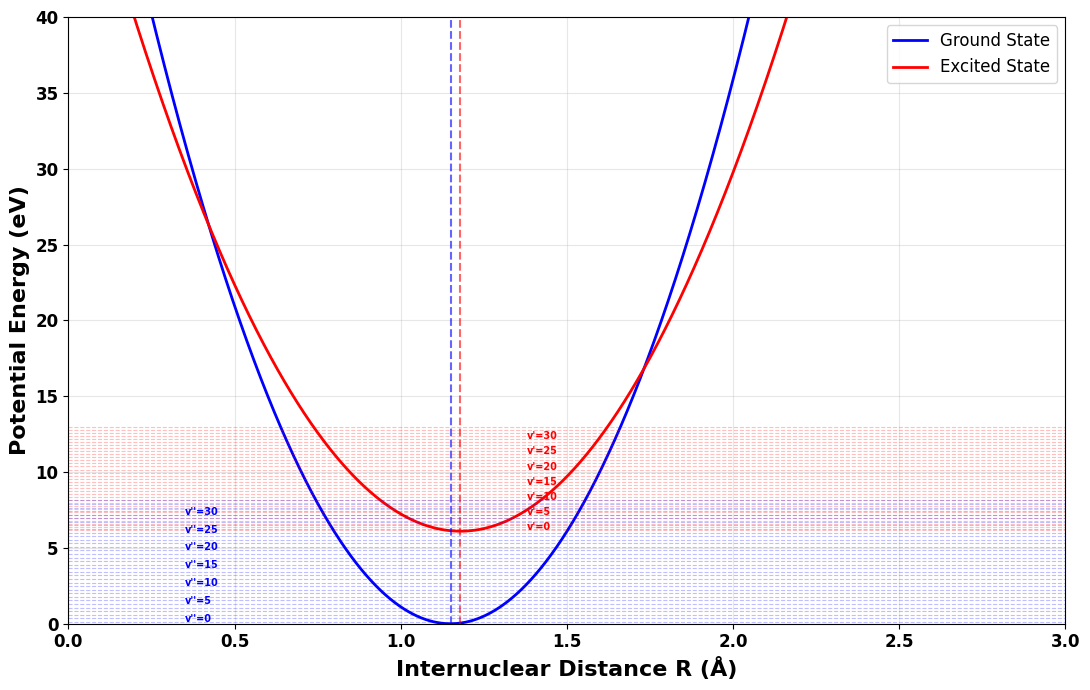

In [ ]:
#NO (K,eV/Å²)
import numpy as np
import matplotlib.pyplot as plt


class FranckCondonCalculator:
   """
   Franck-Condon diagram for NO
   with dynamic scaling and 35 vibrational levels
   """

   def __init__(self, molecule_data):
       self.Re_g = molecule_data['Re_g']
       self.Re_e = molecule_data['Re_e']
       self.k_g = molecule_data['k_g']
       self.k_e = molecule_data['k_e']
       self.mu = molecule_data['mu']
       self.E_e = molecule_data['E_e']

       self._calculate_frequencies()
       self._calculate_alpha_parameters()

   def _calculate_frequencies(self):
       k_g_SI = self.k_g * 16.02176634
       k_e_SI = self.k_e * 16.02176634

       self.omega_g = np.sqrt(k_g_SI / self.mu)
       self.omega_e = np.sqrt(k_e_SI / self.mu)

       print(f"ωg = {self.omega_g:.2e} rad/s")
       print(f"ωe = {self.omega_e:.2e} rad/s")

   def _calculate_alpha_parameters(self):
       hbar = 1.054571817e-34

       self.alpha_g = np.sqrt(self.mu * self.omega_g / hbar) * 1e-10
       self.alpha_e = np.sqrt(self.mu * self.omega_e / hbar) * 1e-10

       print(f"αg = {self.alpha_g:.2e} Å⁻¹")
       print(f"αe = {self.alpha_e:.2e} Å⁻¹")

   def _compute_vibrational_levels(self):
       max_v = 35

       hbar = 1.054571817e-34
       eV_to_J = 1.602176634e-19

       E_vib_g = [(v + 0.5) * hbar * self.omega_g / eV_to_J for v in range(max_v)]
       E_vib_e = [(v + 0.5) * hbar * self.omega_e / eV_to_J + self.E_e for v in range(max_v)]

       return E_vib_g, E_vib_e, max_v

   def plot_potential_curves_and_levels(self):
       # 🔥 Centered R range
       R_min = 0.0
       R_max = 3.0
       R = np.linspace(R_min, R_max, 3000)

       # Potential curves
       V_g = 0.5 * self.k_g * (R - self.Re_g) ** 2
       V_e = self.E_e + 0.5 * self.k_e * (R - self.Re_e) ** 2

       # Ground state minimum (from plotted data)
       min_g_index = np.argmin(V_g)
       print("Ground state minimum:")
       print("R =", R[min_g_index], "Å")
       print("Energy =", V_g[min_g_index], "eV")

       # Excited state minimum
       min_e_index = np.argmin(V_e)
       print("\nExcited state minimum:")
       print("R =", R[min_e_index], "Å")
       print("Energy =", V_e[min_e_index], "eV")

       # Vibrational levels
       E_vib_g, E_vib_e, max_v = self._compute_vibrational_levels()

       plt.figure(figsize=(11, 7))

       # 🔵 Ground, 🔴 Excited
       plt.plot(R, V_g, color='blue', linewidth=2, label='Ground State')
       plt.plot(R, V_e, color='red', linewidth=2, label='Excited State')

       # Equilibrium lines
       plt.axvline(self.Re_g, color='blue', linestyle='--', alpha=0.6)
       plt.axvline(self.Re_e, color='red', linestyle='--', alpha=0.6)

       # Vibrational levels
       for v in range(max_v):
           plt.axhline(E_vib_g[v], color='blue', linestyle='--', alpha=0.25, linewidth=0.8)
           plt.axhline(E_vib_e[v], color='red', linestyle='--', alpha=0.25, linewidth=0.8)

           if v % 5 == 0:
               plt.text(self.Re_g - 0.8, E_vib_g[v], f"v''={v}", fontsize=7,weight='bold', color='blue')
               plt.text(self.Re_e + 0.2, E_vib_e[v], f"v'={v}", fontsize=7, weight='bold', color='red')

       plt.ylim(0,40)

       # Labels
       plt.xlabel('Internuclear Distance R (Å)', fontsize=16, weight='bold')
       plt.ylabel('Potential Energy (eV)', fontsize=16, weight='bold')
       plt.xticks(fontsize=12, weight='bold')  # Increase font size for x axis tick marks
       plt.yticks(fontsize=12, weight='bold')  # Increase font size for y axis tick marks
       plt.legend( fontsize=12)
       plt.xlim(R_min, R_max)
       plt.grid(alpha=0.3)

       plt.tight_layout()
       plt.savefig("NO_dynamic.png", dpi=300)
       plt.show()


def main():
   NO_data = {
       'Re_g': 1.150,
       'Re_e': 1.18,
       'k_g': 99.24,
       'k_e': 70.31,
       'mu': 1.24e-26,
       'E_e': 6.1
   }

   print("Franck-Condon Potential Energy Analysis for NO")
   print("=" * 45)

   fc_calc = FranckCondonCalculator(NO_data)
   fc_calc.plot_potential_curves_and_levels()


if __name__ == "__main__":
   main()
